In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy
from scipy import odr

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [33]:
df0 = pd.read_csv('./models/BFreqRatiosUncertain.csv', skiprows=2,
                 usecols=[0,2,3,4,5], names=['Freq', 'Rb85', 'Rb85_err', 'Rb87', 'Rb87_err'])
df1 = pd.read_csv('./models/quadraticRb85ZeemanData.csv', skiprows=2,
                 usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13], names=['Freq','dip1','udip1','dip2','udip2','dip3','udip3','dip4','udip4','dip5','udip5','dip6','udip6'])
df2 = pd.read_csv('./models/quadraticRb87ZeemanData.csv', skiprows=2,
                 usecols=[0,2,3,4,5,6,7,8,9], names=['Freq','dip1','udip1','dip2','udip2','dip3','udip3','dip4','udip4'])

bAdjustment = 1.034

freqLow = df0['Freq'].values / 1000 # MHz
freq85High = df1['Freq'].values # MHz
freq87High = df2['Freq'].values # MHz


Rb85Low = df0['Rb85'].values # B field in T
uRb85Low = df0['Rb85_err'].values # B field in T

Rb87Low = df0['Rb87'].values # B field in T
uRb87Low = df0['Rb87_err'].values # B field in T


Rb85HighD1 = bAdjustment * df1['dip1'].values # B field in T
Rb85HighD2 = bAdjustment * df1['dip2'].values # B field in T
Rb85HighD3 = bAdjustment * df1['dip3'].values # B field in T
Rb85HighD4 = bAdjustment * df1['dip4'].values # B field in T
Rb85HighD5 = bAdjustment * df1['dip5'].values # B field in T
Rb85HighD6 = bAdjustment * df1['dip6'].values # B field in T
uRb85HighD1 = bAdjustment * df1['udip1'].values # B field in T
uRb85HighD2 = bAdjustment * df1['udip2'].values # B field in T
uRb85HighD3 = bAdjustment * df1['udip3'].values # B field in T
uRb85HighD4 = bAdjustment * df1['udip4'].values # B field in T
uRb85HighD5 = bAdjustment * df1['udip5'].values # B field in T
uRb85HighD6 = bAdjustment * df1['udip6'].values # B field in T

Rb87HighD1 = bAdjustment * df2['dip1'].values # B field in T
Rb87HighD2 = bAdjustment * df2['dip2'].values # B field in T
Rb87HighD3 = bAdjustment * df2['dip3'].values # B field in T
Rb87HighD4 = bAdjustment * df2['dip4'].values # B field in T
uRb87HighD1 = bAdjustment * df2['udip1'].values # B field in T
uRb87HighD2 = bAdjustment * df2['udip2'].values # B field in T
uRb87HighD3 = bAdjustment * df2['udip3'].values # B field in T
uRb87HighD4 = bAdjustment * df2['udip4'].values # B field in T


freq85 = np.concatenate((freqLow, freq85High))

Rb85d1 = np.concatenate((Rb85Low,Rb85HighD1))
Rb85d2 = np.concatenate((Rb85Low,Rb85HighD2))
Rb85d3 = np.concatenate((Rb85Low,Rb85HighD3))
Rb85d4 = np.concatenate((Rb85Low,Rb85HighD4))
Rb85d5 = np.concatenate((Rb85Low,Rb85HighD5))
Rb85d6 = np.concatenate((Rb85Low,Rb85HighD6))

uRb85d1 = np.concatenate((uRb85Low,uRb85HighD1))
uRb85d2 = np.concatenate((uRb85Low,uRb85HighD2))
uRb85d3 = np.concatenate((uRb85Low,uRb85HighD3))
uRb85d4 = np.concatenate((uRb85Low,uRb85HighD4))
uRb85d5 = np.concatenate((uRb85Low,uRb85HighD5))
uRb85d6 = np.concatenate((uRb85Low,uRb85HighD6))


freq87 = np.concatenate((freqLow, freq87High))

Rb87d1 = np.concatenate((Rb87Low,Rb87HighD1))
Rb87d2 = np.concatenate((Rb87Low,Rb87HighD2))
Rb87d3 = np.concatenate((Rb87Low,Rb87HighD3))
Rb87d4 = np.concatenate((Rb87Low,Rb87HighD4))

uRb87d1 = np.concatenate((uRb87Low,uRb87HighD1))
uRb87d2 = np.concatenate((uRb87Low,uRb87HighD2))
uRb87d3 = np.concatenate((uRb87Low,uRb87HighD3))
uRb87d4 = np.concatenate((uRb87Low,uRb87HighD4))

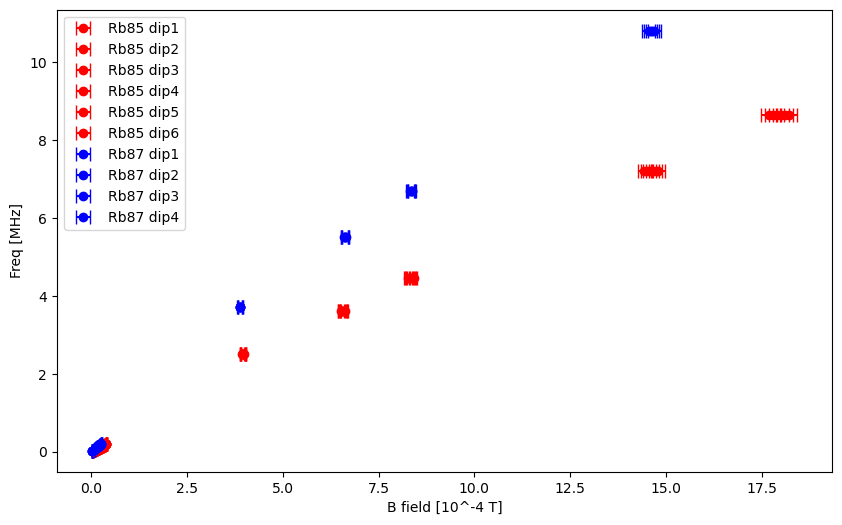

In [35]:
plt.figure(figsize=(10, 6))
plt.errorbar(Rb85d1 * 10**4, freq85, xerr=uRb85d1 * 10**4, capsize=5, label='Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d2 * 10**4, freq85, xerr=uRb85d2 * 10**4, capsize=5, label='Rb85 dip2', fmt='o', color='red')
plt.errorbar(Rb85d3 * 10**4, freq85, xerr=uRb85d3 * 10**4, capsize=5, label='Rb85 dip3', fmt='o', color='red')
plt.errorbar(Rb85d4 * 10**4, freq85, xerr=uRb85d4 * 10**4, capsize=5, label='Rb85 dip4', fmt='o', color='red')
plt.errorbar(Rb85d5 * 10**4, freq85, xerr=uRb85d5 * 10**4, capsize=5, label='Rb85 dip5', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, freq85, xerr=uRb85d6 * 10**4, capsize=5, label='Rb85 dip6', fmt='o', color='red')


plt.errorbar(Rb87d1 * 10**4, freq87, xerr=uRb87d1 * 10**4, capsize=5, label='Rb87 dip1', fmt='o', color='blue')
plt.errorbar(Rb87d2 * 10**4, freq87, xerr=uRb87d2 * 10**4, capsize=5, label='Rb87 dip2', fmt='o', color='blue')
plt.errorbar(Rb87d3 * 10**4, freq87, xerr=uRb87d3 * 10**4, capsize=5, label='Rb87 dip3', fmt='o', color='blue')
plt.errorbar(Rb87d4 * 10**4, freq87, xerr=uRb87d4 * 10**4, capsize=5, label='Rb87 dip4', fmt='o', color='blue')


# Labels and formatting
plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
# plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor quadratic range Mar13", dpi=300)

plt.show()

In [49]:
h = 6.626 * 10**(-34)
gF87 = 0.4988
gF85 = 0.3337
muB = 9.2740 * 10**(-24) # J/T
gJ = 2.002331
gI = 6.6743 * 10**(-11) #m^3 /kgs^2

dEhfs87 =  4.528 * 10**(-24) #J (from gemini)
dEhfs85 =  2.011 * 10**(-24) #J (from gemini)
#M_F is the integer for the associated dip number

# def MHzToE(freqArr):
#     return freqArr / 10**6 * h
#
# def kHzToE(freqArr):
#     return freqArr / 10**3 * h

def quadratic_func(x,a,b,c):
    return a*x**2 + b*x + c

def quadratic_0intercept(p, x):
    # ODR expects parameters as a list/array 'p'
    # a = p[0], b = p[1]
    # y = a*x^2 + b*x
    return p[0] * x**2 + p[1] * x

def fitQuadraticZeeman(B, uB, freq, Mf):
    quad_model = odr.Model(quadratic_0intercept)

    my_data = odr.RealData(B, freq * 10 ** 6, sx=uB) # convert frequency from MHz to Hz

    # b = g_F mu_B/h -> g_F = b h/mu_B
    # a = (g_J - g_I)^2 mu_B^2/(h^2 \Delta Ehfs) (1 - 2M_F)

    aExpected = (gJ - gI)**2 * muB**2/(h*2 * dEhfs85) * (1 - 2*Mf)
    bExpected = (0.3337 * muB) /h

    p0 = [aExpected, bExpected]
    my_odr = odr.ODR(my_data, quad_model, beta0=p0)

    output = my_odr.run()

    a_fit, b_fit = output.beta
    a_err, b_err = output.sd_beta

    a = ufloat(a_fit,a_err)
    b = ufloat(b_fit,b_err)

    print(f"a fit: {a:.1ue}, expect {aExpected:.6e}")
    print(f"b fit: {b:.1ue}, expect {bExpected:.6e}")
    return a,b, aExpected, bExpected, output

#f ~= (g_F mu_B/h) B + (g_J - g_I)^2 mu_B^2/(h^2 deltaE_hfs) (1 - 2M_F) B^2
# calling quadratic func we get a=(g_J - g_I)^2 mu_B^2/(h*2 deltaE_hfs) (1 - 2M_F), b=(g_F mu_B/h), c=0

# use scipy.odr to fit with the B field uncertainty (only have xerr, no yerr)


In [65]:
a85d1,b85d1, a85d1Expected, b85d1Expected, output85d1 = fitQuadraticZeeman(Rb85HighD1, uRb85HighD1,freq85High, 3)
a85d2,b85d2, a85d2Expected, b85d2Expected, output85d2 = fitQuadraticZeeman(Rb85HighD2, uRb85HighD2, freq85High, 2)
a85d3,b85d3, a85d3Expected, b85d3Expected, output85d3 = fitQuadraticZeeman(Rb85HighD3, uRb85HighD3, freq85High, 1)
a85d5,b85d5, a85d5Expected, b85d5Expected, output85d4 = fitQuadraticZeeman(Rb85HighD4, uRb85HighD4, freq85High, -1)
a85d5,b85d5, a85d5Expected, b85d5Expected, output85d5 = fitQuadraticZeeman(Rb85HighD5, uRb85HighD5, freq85High, -2)
a85d6,b85d6, a85d6Expected, b85d6Expected, output85d6 = fitQuadraticZeeman(Rb85HighD6, uRb85HighD6, freq85High, -3)

a87d1,b87d1, a87d1Expected, b87d1Expected, output87d1 = fitQuadraticZeeman(Rb87HighD1, uRb87HighD1, freq87High, 2)
a87d2,b87d2, a87d2Expected, b87d2Expected, output87d2 = fitQuadraticZeeman(Rb87HighD2, uRb87HighD2, freq87High, 1)
a87d3,b87d3, a87d3Expected, b87d3Expected, output87d3 = fitQuadraticZeeman(Rb87HighD3, uRb87HighD3, freq87High, -1)
a87d4,b87d4, a87d4Expected, b87d4Expected, output87d4 = fitQuadraticZeeman(Rb87HighD4, uRb87HighD4, freq87High, -2)

bFullAxis = np.linspace(0,20/10**4)

a fit: (-8+/-2)e+11, expect -6.469675e+11
b fit: (6.2+/-0.3)e+09, expect 4.670591e+09
a fit: (-8+/-2)e+11, expect -3.881805e+11
b fit: (6.2+/-0.3)e+09, expect 4.670591e+09
a fit: (-8+/-2)e+11, expect -1.293935e+11
b fit: (6.1+/-0.3)e+09, expect 4.670591e+09
a fit: (-8+/-2)e+11, expect 3.881805e+11
b fit: (6.1+/-0.3)e+09, expect 4.670591e+09
a fit: (-8+/-2)e+11, expect 6.469675e+11
b fit: (6.1+/-0.3)e+09, expect 4.670591e+09
a fit: (-8+/-2)e+11, expect 9.057544e+11
b fit: (6.1+/-0.3)e+09, expect 4.670591e+09
a fit: (-1.5+/-0.4)e+12, expect -3.881805e+11
b fit: (9.5+/-0.5)e+09, expect 4.670591e+09
a fit: (-1.5+/-0.4)e+12, expect -1.293935e+11
b fit: (9.5+/-0.5)e+09, expect 4.670591e+09
a fit: (-1.5+/-0.4)e+12, expect 3.881805e+11
b fit: (9.5+/-0.5)e+09, expect 4.670591e+09
a fit: (-1.5+/-0.4)e+12, expect 6.469675e+11
b fit: (9.5+/-0.5)e+09, expect 4.670591e+09


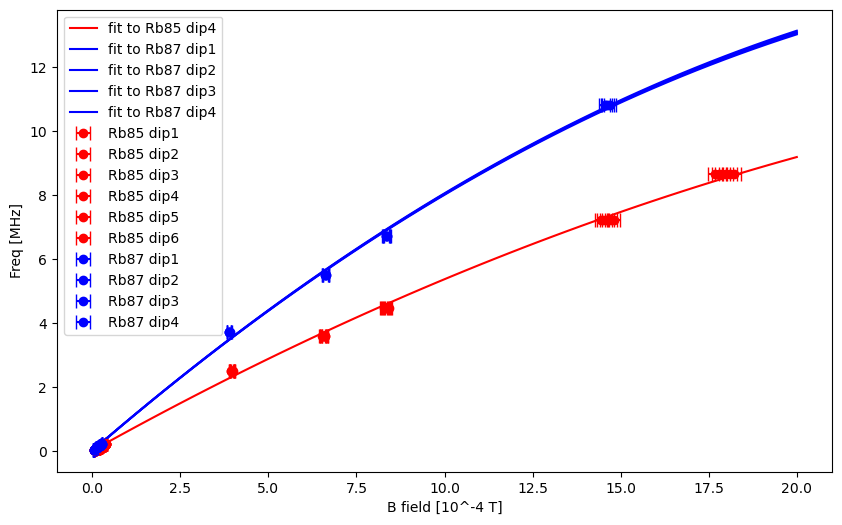

In [66]:
plt.figure(figsize=(10, 6))
plt.errorbar(Rb85d1 * 10**4, freq85, xerr=uRb85d1 * 10**4, capsize=5, label='Rb85 dip1', fmt='o', color='red')
plt.errorbar(Rb85d2 * 10**4, freq85, xerr=uRb85d2 * 10**4, capsize=5, label='Rb85 dip2', fmt='o', color='red')
plt.errorbar(Rb85d3 * 10**4, freq85, xerr=uRb85d3 * 10**4, capsize=5, label='Rb85 dip3', fmt='o', color='red')
plt.errorbar(Rb85d4 * 10**4, freq85, xerr=uRb85d4 * 10**4, capsize=5, label='Rb85 dip4', fmt='o', color='red')
plt.errorbar(Rb85d5 * 10**4, freq85, xerr=uRb85d5 * 10**4, capsize=5, label='Rb85 dip5', fmt='o', color='red')
plt.errorbar(Rb85d6 * 10**4, freq85, xerr=uRb85d6 * 10**4, capsize=5, label='Rb85 dip6', fmt='o', color='red')

plt.errorbar(Rb87d1 * 10**4, freq87, xerr=uRb87d1 * 10**4, capsize=5, label='Rb87 dip1', fmt='o', color='blue')
plt.errorbar(Rb87d2 * 10**4, freq87, xerr=uRb87d2 * 10**4, capsize=5, label='Rb87 dip2', fmt='o', color='blue')
plt.errorbar(Rb87d3 * 10**4, freq87, xerr=uRb87d3 * 10**4, capsize=5, label='Rb87 dip3', fmt='o', color='blue')
plt.errorbar(Rb87d4 * 10**4, freq87, xerr=uRb87d4 * 10**4, capsize=5, label='Rb87 dip4', fmt='o', color='blue')


# plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d1.beta, bFullAxis) / 10**6, label='fit to Rb85 dip1', color='red')
# plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d2.beta, bFullAxis) / 10**6, label='fit to Rb85 dip2', color='red')
# plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d3.beta, bFullAxis) / 10**6, label='fit to Rb85 dip3', color='red')
plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d4.beta, bFullAxis) / 10**6, label='fit to Rb85 dip4', color='red')
# plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d5.beta, bFullAxis) / 10**6, label='fit to Rb85 dip5', color='red')
# plt.plot(bFullAxis * 10**4, quadratic_0intercept(output85d6.beta, bFullAxis) / 10**6, label='fit to Rb85 dip6', color='red')

plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d1.beta, bFullAxis) / 10**6, label='fit to Rb87 dip1', color='blue')
plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d2.beta, bFullAxis) / 10**6, label='fit to Rb87 dip2', color='blue')
plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d3.beta, bFullAxis) / 10**6, label='fit to Rb87 dip3', color='blue')
plt.plot(bFullAxis * 10**4, quadratic_0intercept(output87d4.beta, bFullAxis) / 10**6, label='fit to Rb87 dip4', color='blue')

# Labels and formatting
plt.ylabel('Freq [MHz]')
plt.xlabel('B field [10^-4 T]')
# plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor quadratic range Mar13", dpi=300)

plt.show()